<a href="https://colab.research.google.com/github/Avi0095/Deep-Learning-Project/blob/main/Human_Activity_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UCI HAR Dataset.zip to UCI HAR Dataset (1).zip


In [ ]:
import zipfile
import io

for fn in uploaded.keys():
    with zipfile.ZipFile(io.BytesIO(uploaded[fn]), 'r') as zip_ref:
        zip_ref.extractall("/content/")

Import the library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

path identify

In [ ]:
train_path = 'UCI HAR Dataset/train/Inertial Signals/'
test_path = 'UCI HAR Dataset/test/Inertial Signals/'
signals = [
    'body_acc_x_', 'body_acc_y_', 'body_acc_z_',
    'body_gyro_x_', 'body_gyro_y_', 'body_gyro_z_',
    'total_acc_x_', 'total_acc_y_', 'total_acc_z_'
]


load raw signal data

In [ ]:
def load_X(path, signals):
    X_list = []
    for signal in signals:
        filename = path + signal + 'train.txt' if 'train' in path else path + signal + 'test.txt'
        data = pd.read_csv(filename, delim_whitespace=True, header=None).values
        X_list.append(data)
    X = np.transpose(np.array(X_list), (1, 2, 0))
    return X

X_train = load_X(train_path, signals)
X_test = load_X(test_path, signals)

/tmp/ipykernel_159/3497067185.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename, delim_whitespace=True, header=None).values
/tmp/ipykernel_159/3497067185.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename, delim_whitespace=True, header=None).values
/tmp/ipykernel_159/3497067185.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename, delim_whitespace=True, header=None).values
/tmp/ipykernel_159/3497067185.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename, delim_whitespace=True, header=None)

load label

In [33]:
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', header=None)[0].values - 1
y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt', header=None)[0].values - 1


one hot encoding

In [ ]:
y_train_ohe = to_categorical(y_train, num_classes=6)
y_test_ohe = to_categorical(y_test, num_classes=6)

Explaratory data analysis

In [ ]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Label distribution in train:")
print(pd.Series(y_train).value_counts())


Train shape: (7352, 128, 9)
Test shape: (2947, 128, 9)
Label distribution in train:
5    1407
4    1374
3    1286
0    1226
1    1073
2     986
Name: count, dtype: int64


plot class distribution

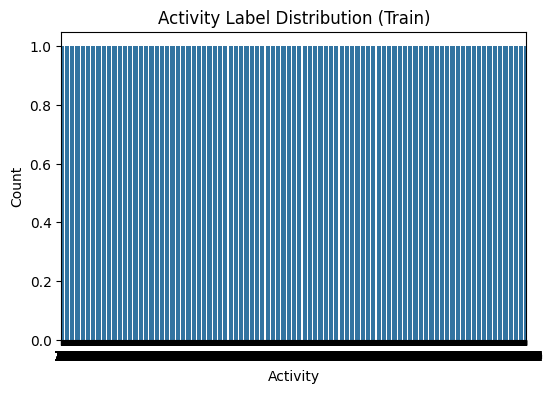

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(y_train)
plt.title("Activity Label Distribution (Train)")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.show()

feature scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = X_train.reshape(-1, 9)
X_test_scaled = X_test.reshape(-1, 9)
X_train_scaled = scaler.fit_transform(X_train_scaled).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test_scaled).reshape(X_test.shape)


build CNN+LSTM model

In [ ]:
model = Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(128,9)))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(100))
model.add(Dropout(0.5))
model.add(Dense(50, activation='relu'))
model.add(Dense(6, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,148 (285.73 KB)

 Trainable params: 73,148 (285.73 KB)

 Non-trainable params: 0 (0.00 B)

train model

In [ ]:
history = model.fit(
    X_train_scaled, y_train_ohe,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_scaled, y_test_ohe)
)

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - accuracy: 0.5694 - loss: 1.0386 - val_accuracy: 0.8076 - val_loss: 0.5673
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.9094 - loss: 0.2567 - val_accuracy: 0.8677 - val_loss: 0.4544
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - accuracy: 0.9230 - loss: 0.1980 - val_accuracy: 0.8626 - val_loss: 0.4509
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 14s 124ms/step - accuracy: 0.9351 - loss: 0.1799 - val_accuracy: 0.9040 - val_loss: 0.3058
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 15s 130ms/step - accuracy: 0.9473 - loss: 0.1237 - val_accuracy: 0.8968 - val_loss: 0.4076
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 13s 113ms/step - accuracy: 0.9468 - loss: 0.1274 - val_accuracy: 0.9050 - val_loss: 0.3695
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 14s 124ms/step - accuracy: 0.9562 - loss: 0.1038 - val_accuracy: 0.8975 - val_loss: 0.5039
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - accuracy: 0.9526 - loss: 0

evaluate model

In [ ]:
loss, acc = model.evaluate(X_test_scaled, y_test_ohe)
print(f'Test Accuracy: {acc*100:.2f}%')


93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8714 - loss: 0.5246
Test Accuracy: 90.60%


In [ ]:
model.save('har_model.h5')
print("Model saved as har_model.h5")

Model saved as har_model.h5


In [ ]:
from google.colab import files
files.download('har_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [ ]:
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

confusion matrix

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


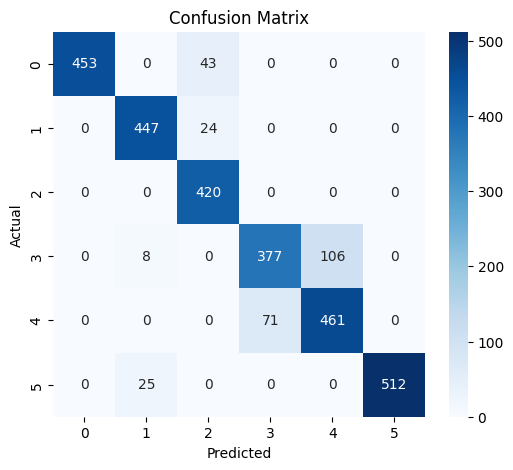

In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

classification report

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, digits=3))

Classification Report:
              precision    recall  f1-score   support

           0      1.000     0.913     0.955       496
           1      0.931     0.949     0.940       471
           2      0.862     1.000     0.926       420
           3      0.842     0.768     0.803       491
           4      0.813     0.867     0.839       532
           5      1.000     0.953     0.976       537

    accuracy                          0.906      2947
   macro avg      0.908     0.908     0.906      2947
weighted avg      0.909     0.906     0.906      2947



In [ ]:
# Dhore X_test_scaled ready ase
sample = X_test_scaled[0]  # first sample
df_sample = pd.DataFrame(sample)  # shape = (128,9)
df_sample.to_csv("sample_input.csv", index=False)
from google.colab import files
files.download("sample_input.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files

# Dhore X_test_scaled ready ache (shape: [num_samples, 128, 9])
sample = X_test_scaled[0]  # first sample

# DataFrame e convert
df_sample = pd.DataFrame(sample)  # shape = (128, 9)

# CSV save
df_sample.to_csv("sample_input.csv", index=False)

# Download
files.download("sample_input.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_sample.to_csv("sample_input.csv", index=False, header=False)
files.download("sample_input.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files

# Dhore X_train_scaled ready ase (shape: [num_samples, 128, 9])
sample = X_train_scaled[0]  # first sample from training set

# 128x9 DataFrame
df_sample = pd.DataFrame(sample)  # shape = (128,9)

# CSV save without index & header
df_sample.to_csv("train_sample_input.csv", index=False, header=False)

# Download
files.download("train_sample_input.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# y_train already loaded, 0-5 integer labels
# activity_map = {0:'Walking',1:'Walking Upstairs',2:'Walking Downstairs',3:'Sitting',4:'Standing',5:'Laying'}

standing_index = np.where(y_train == 4)[0][0]  # first training sample with label 'Standing'

In [ ]:
import pandas as pd
from google.colab import files

# select the sample
sample = X_train_scaled[standing_index]  # shape = (128,9)

# create DataFrame
df_sample = pd.DataFrame(sample)

# save CSV without index & header
df_sample.to_csv("standing_sample.csv", index=False, header=False)

# download
files.download("standing_sample.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from google.colab import files

# Dhore: X_train_scaled, y_train already ready
# activity mapping
activity_map = {
    0: 'Walking',
    1: 'Walking Upstairs',
    2: 'Walking Downstairs',
    3: 'Sitting',
    4: 'Standing',
    5: 'Laying'
}

# loop over each activity
for label, activity_name in activity_map.items():
    # find first sample of this activity
    indices = np.where(y_train == label)[0]
    if len(indices) == 0:
        print(f"No sample for {activity_name}")
        continue
    sample_index = indices[0]

    # original X_train sample (scaled or unscaled depending on your Streamlit scaler)
    sample = X_train[sample_index]  # shape: (128,9)

    # create DataFrame
    df_sample = pd.DataFrame(sample)

    # save CSV without index & header
    csv_name = f"{activity_name.replace(' ', '_')}_sample.csv"
    df_sample.to_csv(csv_name, index=False, header=False)

    # download
    files.download(csv_name)
    print(f"{csv_name} ready for Streamlit upload")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Walking_sample.csv ready for Streamlit upload


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Standing_sample.csv ready for Streamlit upload


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Laying_sample.csv ready for Streamlit upload
